<a href="https://colab.research.google.com/github/sandhyarambha/Sales_forecasting-Revenue_Analysis/blob/main/Sales_Forecasting_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd

path = "/content/drive/MyDrive/Data_Analysis_Project/"

train = pd.read_csv(path + "train.csv")
test = pd.read_csv(path + "test.csv")
stores = pd.read_csv(path + "stores.csv")
features = pd.read_csv(path + "features.csv")

In [6]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [7]:
train.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')

In [8]:
stores.columns

Index(['Store', 'Type', 'Size'], dtype='object')

In [9]:
features.columns

Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday'],
      dtype='object')

In [12]:
train = train.merge(stores, on='Store', how='left')

In [17]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type_x,Size_x,Type_y,Size_y,Type,...,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,A,151315,A,...,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,A,151315,A,151315,A,...,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,A,151315,A,151315,A,...,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,A,151315,A,151315,A,...,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,A,151315,A,151315,A,...,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [14]:
train = train.merge(features, on=['Store','Date'], how='left')

In [16]:
train['Date'] = pd.to_datetime(train['Date'])

In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Type_x        421570 non-null  object        
 6   Size_x        421570 non-null  int64         
 7   Type_y        421570 non-null  object        
 8   Size_y        421570 non-null  int64         
 9   Type          421570 non-null  object        
 10  Size          421570 non-null  int64         
 11  Temperature   421570 non-null  float64       
 12  Fuel_Price    421570 non-null  float64       
 13  MarkDown1     150681 non-null  float64       
 14  MarkDown2     111248 non-null  float64       
 15  MarkDown3     137

/tmp/ipython-input-946787269.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = train.groupby(pd.Grouper(key='Date', freq='M'))['Weekly_Sales'].sum()


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Date'>

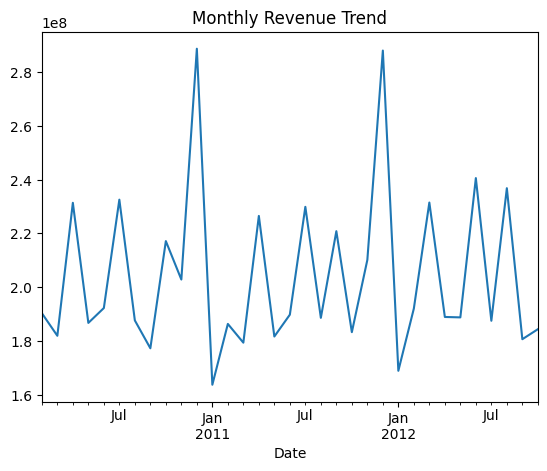

In [19]:
monthly_sales = train.groupby(pd.Grouper(key='Date', freq='M'))['Weekly_Sales'].sum()

monthly_sales.plot(title="Monthly Revenue Trend")

<Axes: title={'center': 'Revenue by Store'}, xlabel='Store'>

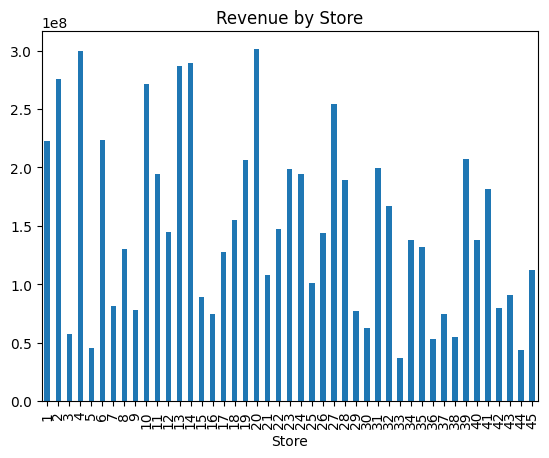

In [20]:
store_sales = train.groupby('Store')['Weekly_Sales'].sum()

store_sales.plot(kind='bar', title="Revenue by Store")

<Axes: title={'center': 'Holiday vs Non-Holiday Sales'}, xlabel='IsHoliday_x'>

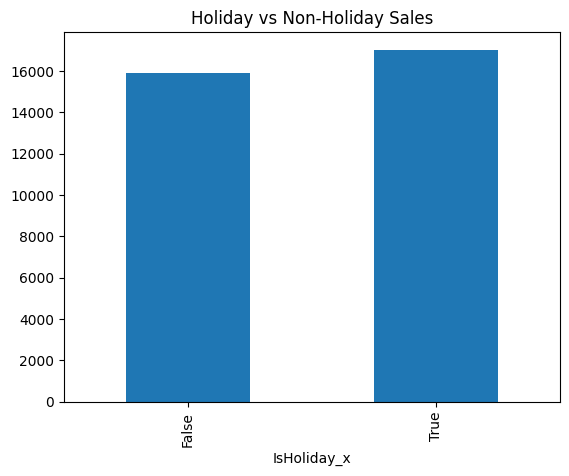

In [22]:
holiday_sales = train.groupby('IsHoliday_x')['Weekly_Sales'].mean()

holiday_sales.plot(kind='bar', title="Holiday vs Non-Holiday Sales")

<Axes: title={'center': 'Monthly Revenue Growth Rate (%)'}, xlabel='Date'>

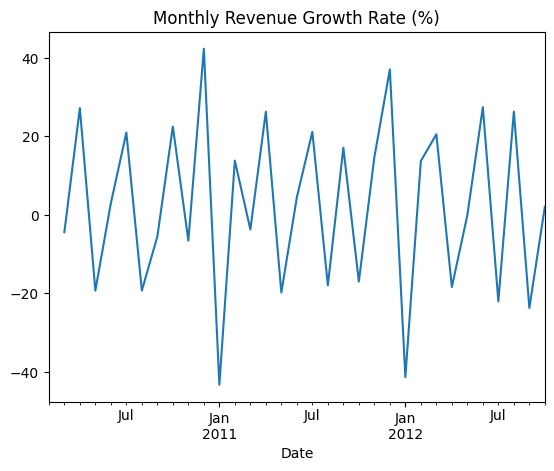

In [23]:
monthly_growth = monthly_sales.pct_change()*100

monthly_growth.plot(title="Monthly Revenue Growth Rate (%)")

In [24]:
daily_sales = train.groupby('Date')['Weekly_Sales'].sum()

In [25]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [26]:
model = ExponentialSmoothing(
    daily_sales,
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [27]:
forecast = model.forecast(30)

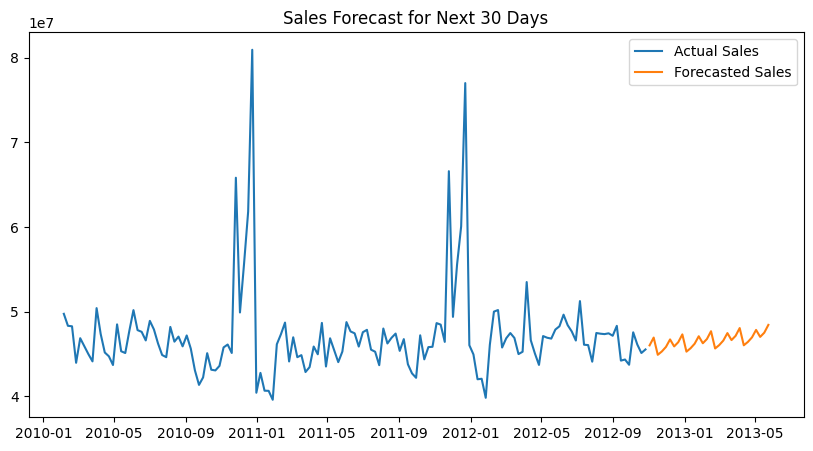

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(daily_sales, label='Actual Sales')
plt.plot(forecast, label='Forecasted Sales')
plt.legend()
plt.title("Sales Forecast for Next 30 Days")
plt.show()